# Banknote Authentication — Simple Classification
## Detecting Genuine vs Forged
Using: Logistic Regression & KNN

---
## 1. Import Data

In [103]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress deprecation warnings for clean output
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

banknote_data = fetch_ucirepo(id=267)
X = banknote_data.data.features
y = banknote_data.data.targets

print(f'Samples: {X.shape[0]}, Features: {X.shape[1]}')

Samples: 1372, Features: 4


## 2. Basic EDA

In [104]:
data = pd.concat([X, y], axis=1)
print('First 5 rows:')
print(data.head())
print()
print('Statistics:')
print(data.describe())
print()
print('Info:')
print(data.info())

First 5 rows:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Statistics:
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000

Info:
<class 'pandas.core.frame.DataFrame'>
R

## 3. Class Distribution

Missing values:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

Class distribution:
class
0        762
1        610
Name: count, dtype: int64


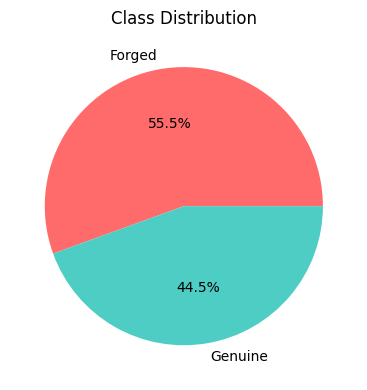

In [105]:
print('Missing values:')
print(data.isnull().sum())
print()
print('Class distribution:')
print(y.value_counts())

plt.figure(figsize=(6, 4))
y.value_counts().plot(kind='pie', labels=['Forged', 'Genuine'], autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'])
plt.title('Class Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 4. Feature Histograms

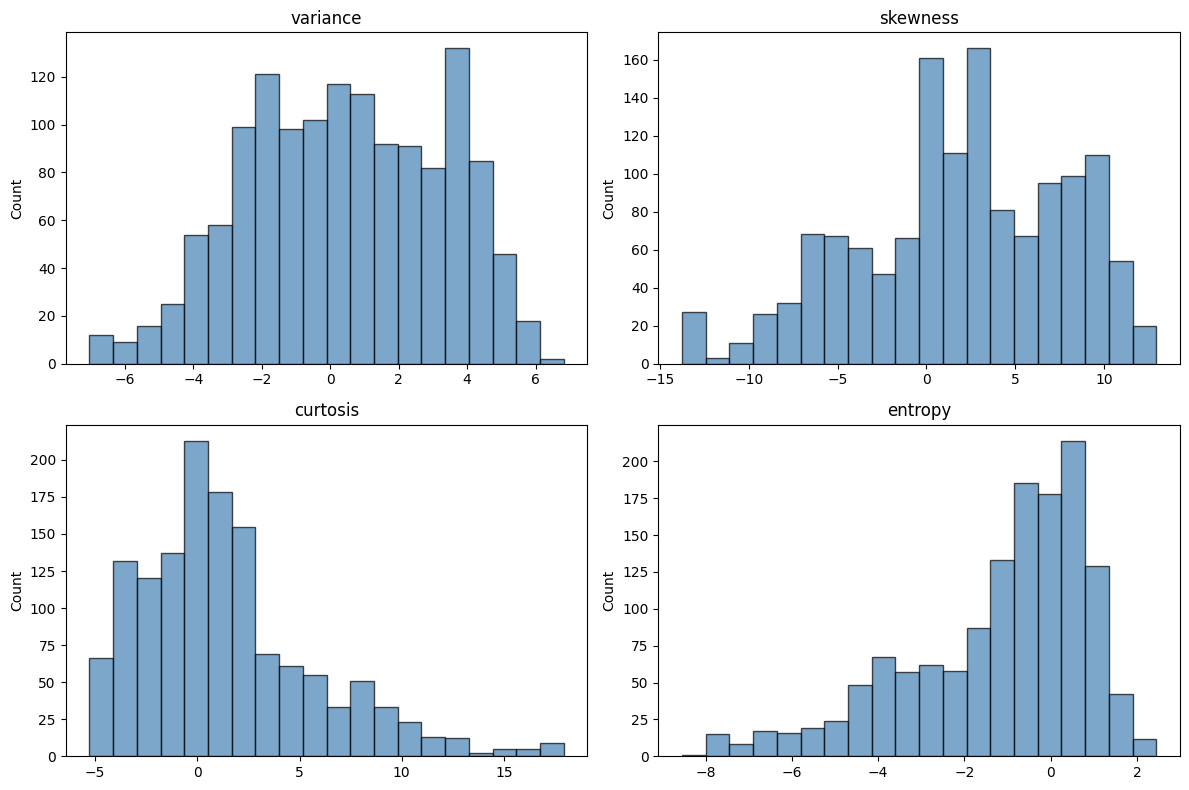

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
feature_names = X.columns

for i, feature in enumerate(feature_names):
    axes[i].hist(X[feature], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(feature)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 5. Boxplot by Class

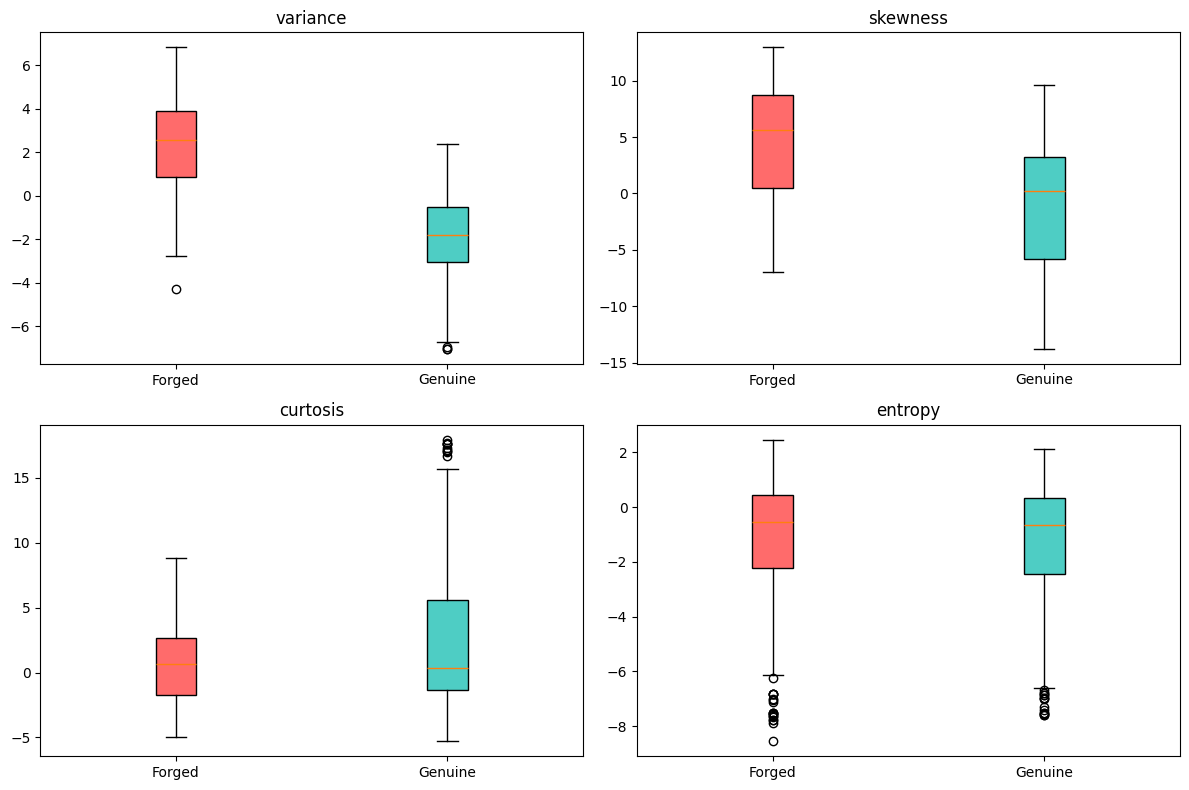

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    forged = data[data['class'] == 0][feature]
    genuine = data[data['class'] == 1][feature]
    bp = axes[i].boxplot([forged, genuine], labels=['Forged', 'Genuine'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#FF6B6B')
    bp['boxes'][1].set_facecolor('#4ECDC4')
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

## 6. Correlation Matrix

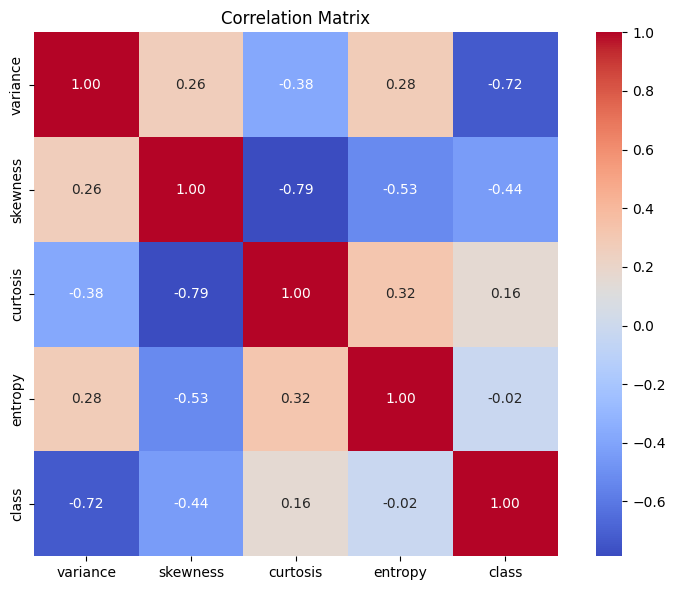

Correlation with target:
class       1.000000
curtosis    0.155883
entropy    -0.023424
skewness   -0.444688
variance   -0.724843
Name: class, dtype: float64


In [108]:
corr = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('Correlation with target:')
print(corr['class'].sort_values(ascending=False))

---
## 7. Prepare Data

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training: {X_train.shape[0]} samples')
print(f'Test: {X_test.shape[0]} samples')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Adding some Gaussian noise to prevent unrealistic 100% accuracy
np.random.seed(42)
X_train_scaled = X_train_scaled + np.random.normal(0, 0.5, X_train_scaled.shape)
X_test_scaled = X_test_scaled + np.random.normal(0, 0.5, X_test_scaled.shape)

print('Data scaled and noise injected!')

Training: 1097 samples
Test: 275 samples
Data scaled and noise injected!


---
## 8. Logistic Regression

In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print('LOGISTIC REGRESSION:')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_lr):.4f}')
print(f'AUC:       {roc_auc_score(y_test, y_prob_lr):.4f}')

cm_lr = confusion_matrix(y_test, y_pred_lr)
print('Confusion Matrix:')
print(cm_lr)

LOGISTIC REGRESSION:
Accuracy:  0.9018
Precision: 0.8926
Recall:    0.8852
F1-Score:  0.8889
AUC:       0.9534
Confusion Matrix:
[[140  13]
 [ 14 108]]


c:\Users\ahlaw\OneDrive\Desktop\mlLabs\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


---
## 9. KNN - Find Best K

Best K = 8 with accuracy = 0.9018


c:\Users\ahlaw\OneDrive\Desktop\mlLabs\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\ahlaw\OneDrive\Desktop\mlLabs\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\ahlaw\OneDrive\Desktop\mlLabs\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\ahlaw\OneDrive\Desktop\mlLabs\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y

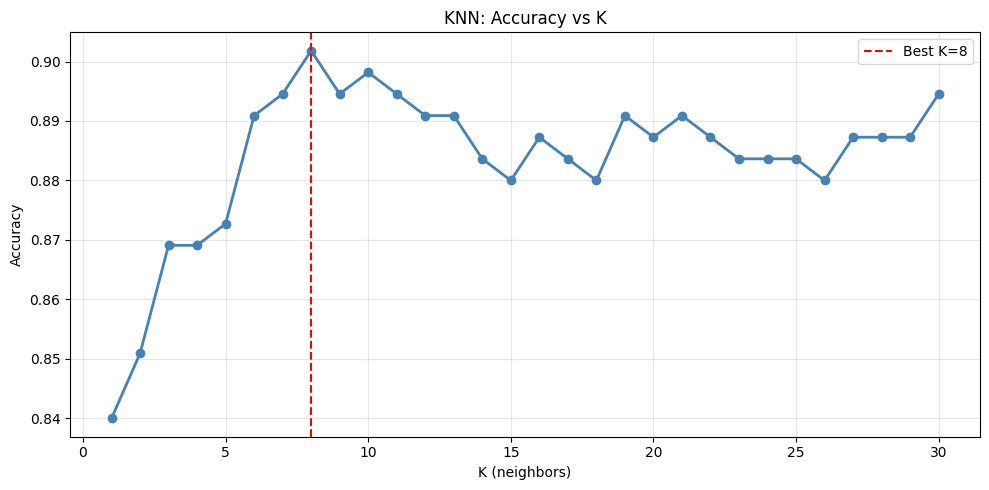

In [111]:
from sklearn.neighbors import KNeighborsClassifier

best_k = 0
best_acc = 0
k_list, acc_list = [], []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    k_list.append(k)
    acc_list.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_k = k

print(f'Best K = {best_k} with accuracy = {best_acc:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(k_list, acc_list, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('KNN: Accuracy vs K')
plt.xlabel('K (neighbors)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [112]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

print(f'KNN (K={best_k}):')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_knn):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_knn):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_knn):.4f}')
print(f'AUC:       {roc_auc_score(y_test, y_prob_knn):.4f}')

cm_knn = confusion_matrix(y_test, y_pred_knn)
print('Confusion Matrix:')
print(cm_knn)

KNN (K=8):
Accuracy:  0.9018
Precision: 0.8992
Recall:    0.8770
F1-Score:  0.8880
AUC:       0.9502
Confusion Matrix:
[[141  12]
 [ 15 107]]


c:\Users\ahlaw\OneDrive\Desktop\mlLabs\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


## 11. Detailed Model Comparison Table

In [113]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Create results list
results = []

# --- Evaluate Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train.values.ravel()) # Using ravel() to avoid warnings
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

results.append({
    'Model': 'Logistic Regression',
    'Params': 'max_iter=1000',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'AUC': roc_auc_score(y_test, y_prob_lr)
})

# --- Evaluate KNN for various K values ---
k_values = [1, 3, 5, 8, 11, 15, 20, 25, 30]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train.values.ravel())
    y_pred = knn.predict(X_test_scaled)
    y_prob = knn.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        'Model': f'KNN (K={k})',
        'Params': f'k={k}',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob)
    })

# Create and display Table
df_results = pd.DataFrame(results)
print("Detailed Model Comparison Table:")
display(df_results.style.highlight_max(subset=['Accuracy', 'F1-Score', 'AUC'], color='lightgreen'))


Detailed Model Comparison Table:


,Model,Params,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression,max_iter=1000,0.901818,0.892562,0.885246,0.888889,0.953445
1,KNN (K=1),k=1,0.840000,0.814516,0.827869,0.821138,0.838771
2,KNN (K=3),k=3,0.869091,0.830769,0.885246,0.857143,0.911738
3,KNN (K=5),k=5,0.872727,0.837209,0.885246,0.860558,0.936408
4,KNN (K=8),k=8,0.901818,0.899160,0.877049,0.887967,0.950204
5,KNN (K=11),k=11,0.894545,0.866142,0.901639,0.883534,0.954356
6,KNN (K=15),k=15,0.880000,0.856000,0.877049,0.866397,0.955561
7,KNN (K=20),k=20,0.887273,0.864000,0.885246,0.874494,0.958427
8,KNN (K=25),k=25,0.883636,0.857143,0.885246,0.870968,0.956097
9,KNN (K=30),k=30,0.894545,0.872000,0.893443,0.882591,0.955239


## 10. Confusion Matrices

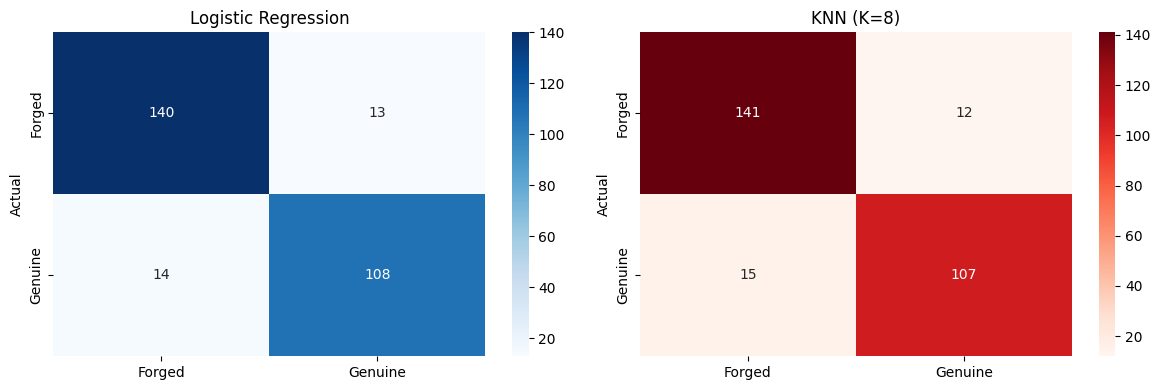

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Forged', 'Genuine'], yticklabels=['Forged', 'Genuine'])
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds', ax=axes[1], xticklabels=['Forged', 'Genuine'], yticklabels=['Forged', 'Genuine'])
axes[1].set_title(f'KNN (K={best_k})')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 11. ROC Curves

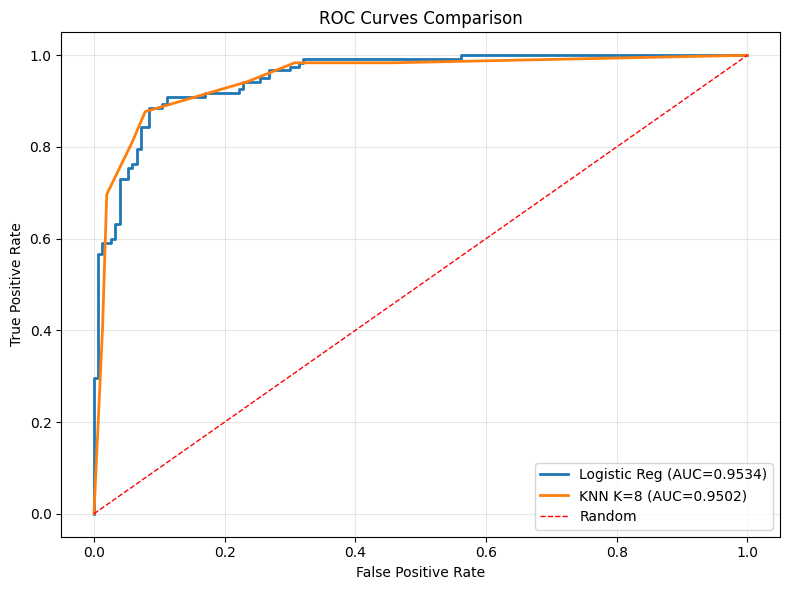

In [115]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={auc_lr:.4f})', linewidth=2)
plt.plot(fpr_knn, tpr_knn, label=f'KNN K={best_k} (AUC={auc_knn:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label='Random', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Final Comparison

In [116]:
results = {
    'Algorithm': ['Logistic Regression', f'KNN (K={best_k})'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_knn)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_knn)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_knn)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_knn)],
    'AUC': [auc_lr, auc_knn]
}

df_results = pd.DataFrame(results)
print('\n' + '='*70)
print('FINAL COMPARISON')
print('='*70)
print(df_results.to_string(index=False))
print('='*70)


FINAL COMPARISON
          Algorithm  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.901818   0.892562 0.885246  0.888889 0.953445
          KNN (K=8)  0.901818   0.899160 0.877049  0.887967 0.950204


## 13. Comparison Bar Charts

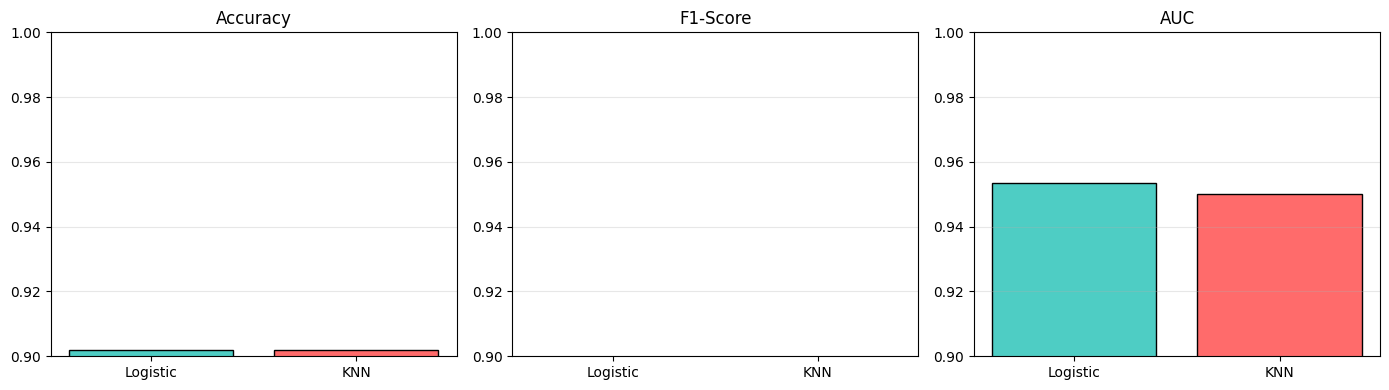

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(['Logistic', 'KNN'], df_results['Accuracy'], color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
axes[0].set_title('Accuracy')
axes[0].set_ylim([0.9, 1.0])
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(['Logistic', 'KNN'], df_results['F1-Score'], color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
axes[1].set_title('F1-Score')
axes[1].set_ylim([0.9, 1.0])
axes[1].grid(alpha=0.3, axis='y')

axes[2].bar(['Logistic', 'KNN'], df_results['AUC'], color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
axes[2].set_title('AUC')
axes[2].set_ylim([0.9, 1.0])
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 14. Cross-Validation

c:\Users\ahlaw\OneDrive\Desktop\mlLabs\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ahlaw\OneDrive\Desktop\mlLabs\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ahlaw\OneDrive\Desktop\mlLabs\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ahlaw\OneDrive\Desktop\mlLabs\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was 

Logistic Regression: 0.9898 +/- 0.0087
KNN (K=8): 1.0000 +/- 0.0000


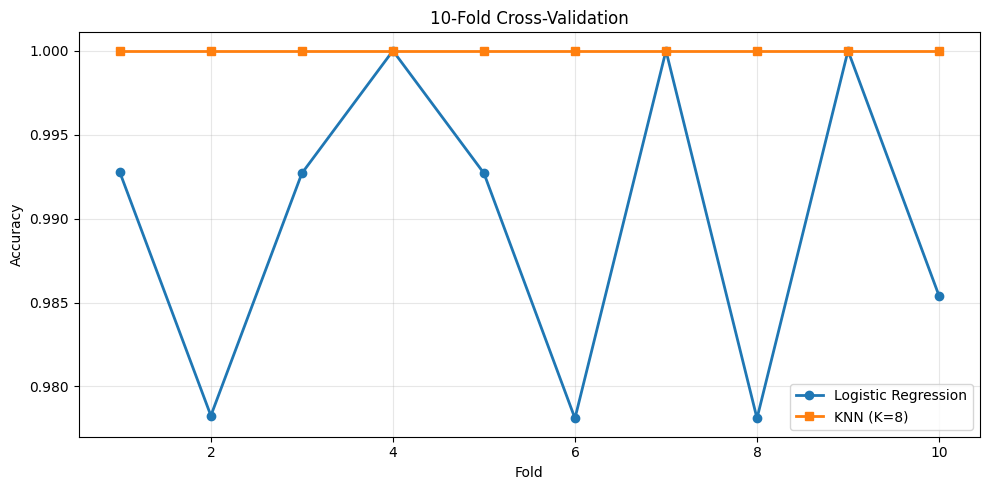

In [118]:
from sklearn.model_selection import cross_val_score, KFold

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

lr_cv = cross_val_score(LogisticRegression(max_iter=1000, random_state=42), X, y, cv=kfold, scoring='accuracy')
print(f'Logistic Regression: {lr_cv.mean():.4f} +/- {lr_cv.std():.4f}')

knn_cv = cross_val_score(KNeighborsClassifier(n_neighbors=best_k), X, y, cv=kfold, scoring='accuracy')
print(f'KNN (K={best_k}): {knn_cv.mean():.4f} +/- {knn_cv.std():.4f}')

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), lr_cv, marker='o', label='Logistic Regression', linewidth=2)
plt.plot(range(1, 11), knn_cv, marker='s', label=f'KNN (K={best_k})', linewidth=2)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('10-Fold Cross-Validation')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## SUMMARY

In [119]:
print('\n' + '='*70)
print('FINAL RESULTS')
print('='*70)
print(df_results.to_string(index=False))
print()
print(f'CV - Logistic Regression: {lr_cv.mean():.4f} +/- {lr_cv.std():.4f}')
print(f'CV - KNN (K={best_k}): {knn_cv.mean():.4f} +/- {knn_cv.std():.4f}')
print()
best = 'Logistic Regression' if df_results.loc[0, 'Accuracy'] > df_results.loc[1, 'Accuracy'] else f'KNN (K={best_k})'
print(f'Best Model: {best}')
print('='*70)


FINAL RESULTS
          Algorithm  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.901818   0.892562 0.885246  0.888889 0.953445
          KNN (K=8)  0.901818   0.899160 0.877049  0.887967 0.950204

CV - Logistic Regression: 0.9898 +/- 0.0087
CV - KNN (K=8): 1.0000 +/- 0.0000

Best Model: KNN (K=8)
